# 파이썬으로 코호트 분석하기

+ https://workingwithpython.com/pythoncohortanalysis/

In [1]:
# import os
# import random #데이터 샘플링
# from collections import Counter # count 용도

import numpy as np
import pandas as pd

# from geopy import distance # 거리 계산
# import geopy.distance
from tqdm import tqdm

import warnings
warnings.filterwarnings('ignore')

# 시각화
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
plt.style.use('fivethirtyeight')

# 한글, 마이너스 깨짐 방지
from matplotlib import rc, font_manager, rcParams
font=font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
rc('font', family = font)
rcParams['axes.unicode_minus'] = False

## 데이터 준비 및 확인하기

In [2]:
df = pd.read_excel('https://github.com/springcoil/marsmodelling/blob/master/relay-foods.xlsx?raw=true',
                    sheet_name='Purchase Data - Full Study')
df.head()

,OrderId,OrderDate,UserId,TotalCharges,CommonId,PupId,PickupDate
0,262,2009-01-11,47,50.67,TRQKD,2,2009-01-12
1,278,2009-01-20,47,26.60,4HH2S,3,2009-01-20
2,294,2009-02-03,47,38.71,3TRDC,2,2009-02-04
3,301,2009-02-06,47,53.38,NGAZJ,2,2009-02-09
4,302,2009-02-06,47,14.28,FFYHD,2,2009-02-09


In [3]:
# 데이터 크기 확인
df.shape

(2891, 7)

In [4]:
# 데이터 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2891 entries, 0 to 2890
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   OrderId       2891 non-null   int64         
 1   OrderDate     2891 non-null   datetime64[ns]
 2   UserId        2891 non-null   int64         
 3   TotalCharges  2891 non-null   float64       
 4   CommonId      2891 non-null   object        
 5   PupId         2891 non-null   int64         
 6   PickupDate    2891 non-null   datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(3), object(1)
memory usage: 158.2+ KB


In [5]:
# 결측치 확인
df.isnull().sum()

OrderId         0
OrderDate       0
UserId          0
TotalCharges    0
CommonId        0
PupId           0
PickupDate      0
dtype: int64

## 데이터 전처리하기

### 코호트 분석을 위한 칼럼 외의 불필요한 칼럼 삭제

In [6]:
df.drop(['CommonId', 'PupId', 'PickupDate', 'TotalCharges'], axis=1, inplace=True)
df.head()

,OrderId,OrderDate,UserId
0,262,2009-01-11,47
1,278,2009-01-20,47
2,294,2009-02-03,47
3,301,2009-02-06,47
4,302,2009-02-06,47


### 주문일자(OrderDate) 컬럼으로 단위 기간 만들기

+ 코호트 분석시 데이터를 집계하기 위한 단위 기간은 보통 **월단위**로 진행된다. 실습 데이터에서 시간을 표현하는 OrderDate 컬럼의 데이터는 일단위로 구성되어 있으므로, 이 컬럼의 데이터를 사용하여 월단위 데이터를 추출할 수 있다.

In [7]:
df['OrderDate'].head()

0   2009-01-11
1   2009-01-20
2   2009-02-03
3   2009-02-06
4   2009-02-06
Name: OrderDate, dtype: datetime64[ns]

In [8]:
df['OrderDate'].dtype

dtype('<M8[ns]')

In [9]:
df['OrderPeriod'] = df['OrderDate'].dt.strftime('%Y-%m')
df.head()

,OrderId,OrderDate,UserId,OrderPeriod
0,262,2009-01-11,47,2009-01
1,278,2009-01-20,47,2009-01
2,294,2009-02-03,47,2009-02
3,301,2009-02-06,47,2009-02
4,302,2009-02-06,47,2009-02


+ dt.accessor

https://pandas.pydata.org/pandas-docs/stable/reference/series.html#datetimelike-properties

### 유저의 첫 번째 주문을 토대로 유저별 코호트 그룹 설정하기

+ 코호트 분석의 전제조건 중 하나인 동일한 경험을 만드는 과정이다. 현재 코호트 분석의 주제는 사용자 유지율 분석인데, 실습 데이터에서의 동일한 경험은 **첫 번째 주문**이다. 각각의 raw에 고객ID별 첫 번째 주문일자를 추가해주자.

In [10]:
df.set_index('UserId', inplace=True)
df.head()

,OrderId,OrderDate,OrderPeriod
UserId,,,
47,262,2009-01-11,2009-01
47,278,2009-01-20,2009-01
47,294,2009-02-03,2009-02
47,301,2009-02-06,2009-02
47,302,2009-02-06,2009-02


In [11]:
# index로 그룹
FirstOrder = df.groupby(df.index)['OrderDate'].min()
FirstOrder.head()

UserId
47    2009-01-11
95    2009-03-10
98    2009-01-29
112   2009-01-19
141   2009-11-13
Name: OrderDate, dtype: datetime64[ns]

In [12]:
FirstOrder = FirstOrder.dt.strftime('%Y-%m')
FirstOrder.head()

UserId
47     2009-01
95     2009-03
98     2009-01
112    2009-01
141    2009-11
Name: OrderDate, dtype: object

In [13]:
df['FirstOrder'] = FirstOrder
df.reset_index(inplace=True)
df.head()

,UserId,OrderId,OrderDate,OrderPeriod,FirstOrder
0,47,262,2009-01-11,2009-01,2009-01
1,47,278,2009-01-20,2009-01,2009-01
2,47,294,2009-02-03,2009-02,2009-01
3,47,301,2009-02-06,2009-02,2009-01
4,47,302,2009-02-06,2009-02,2009-01


위 셀의 첫 행처럼 index가 UserId인 기존 데이터프레임(df)에 FirstOrder변수로 FirstOrder컬럼을 추가하면 df와 FirstOrder의 동일한 인덱스를 기준으로 데이터를 배치해준다. 그리고 reset_index함수를 사용한 결과를 살펴보면 기존 데이터프레임의 각 raw에 첫 주문일자가 입력된 것을 확인할 수 있다.

### 코호트 그룹과 주문기간으로 데이터 집계하기

고객들이 우리 홈페이지에 방문한 횟수를 집계하는 방법에 대해 살펴보자. 고객들이 우리의 홈페이지를 처음 방문한 후, 자신의 니즈에 따라 계속적으로 이용할 수도 있고, 이용하지 않을 수도 있다.

그러나 사용자 유지율을 파악하기 위한 코호트 분석에서는 각각의 방문을 모두 집계하는 것이 아니라 순방문자(UV)로 집계해야 한다.

In [14]:
grouped = df.groupby(['FirstOrder', 'OrderPeriod'])

groupby 함수에 첫 주문일자를 나타내는 FirstOrder와 주문별 기간을 나타내는 OrderPeriod를 함께 전달하여 첫 방문기간과 주문기간을 기준으로 데이터를 그룹화 한다.

In [15]:
cohorts = grouped['UserId'].nunique()
cohorts.head()

FirstOrder  OrderPeriod
2009-01     2009-01        22
            2009-02         8
            2009-03        10
            2009-04         9
            2009-05        10
Name: UserId, dtype: int64

grouped 객체에 고객아이디(UserId)를 집계하며, 집계함수로 각 unique값의 개수를 세는 nunique함수를 사용한다. 이렇게 코딩하면 고객이 여러번 방문했다 하더라도 한 번으로 집계하게 되어 월별 순방문자수를 파악할 수 있다.

In [16]:
cohorts = cohorts.reset_index()
cohorts.head()

,FirstOrder,OrderPeriod,UserId
0,2009-01,2009-01,22
1,2009-01,2009-02,8
2,2009-01,2009-03,10
3,2009-01,2009-04,9
4,2009-01,2009-05,10


reset_index함수를 사용한 데이터프레임을 살펴보면 FirstOrder, OrderPeriod, UserId 컬럼으로 구성되어 있는 것을 살펴볼 수 있다. 그런데 UserId 컬럼은 처음 데이터를 가져왔을 때 47, 98, 112, 141 등 고객별 UserId 데이터로 구성되어 있었는데, 현재는 순방문자수를 집계한 데이터로 구성되어 있다.

In [17]:
# 컬럼 이름 변경
cohorts.rename({'UserId':'TotalUsers'}, axis=1, inplace=True)
cohorts.head()

,FirstOrder,OrderPeriod,TotalUsers
0,2009-01,2009-01,22
1,2009-01,2009-02,8
2,2009-01,2009-03,10
3,2009-01,2009-04,9
4,2009-01,2009-05,10


### 데이터가 없는 기간 체크 및 전처리하기

코호트 분석 화면을 보면 기간을 표현하는 컬럼(x축)은 0부터 9까지 표기 되어있다. 고객이 언제 구매하였던 간에 처음 들어온 기간은 0, 두 번째 들어온 기간은 1, 세 번째 들어온 기간은 3으로 표기한다.

모든 기간을 종합해보면, 첫 번째 코호트(y축의 첫 번째)에 N번의 기간이 있다고 가정하면 두 번째 코호트에는 (N-1)번, 세 번째 코호트에는 (N-2)번, ... 마지막 코호트에는 기간이 1번 생성되어야 한다. 그렇다면 실습 데이터도 이러한 형식을 가졌는지 확인해보자.

In [18]:
each_period = cohorts['FirstOrder'].value_counts().sort_index()
each_period

2009-01    15
2009-02    13
2009-03    13
2009-04    12
2009-05    11
2009-06    10
2009-07     9
2009-08     8
2009-09     7
2009-10     6
2009-11     5
2009-12     4
2010-01     3
2010-02     2
2010-03     1
Name: FirstOrder, dtype: int64

첫 주문(동일한 경험) 데이터가 있는 데이터프레임의 FirstOrder컬럼에 value_counts함수를 사용하여 unique value별로 카운팅 한 후, sort_index함수를 사용하여 인덱스를 오름차순 정렬하여 살펴보면 위의 결과와 같다.

그런데 첫 번째 코호트 기간은 15번으로 구성되어 있기 때문에 두 번째 코호트 기간은 15-1=14여야 하는데 13인 것을 확인할 수 있다. 그 외의 데이터를 살펴보면 13, 12, 11, 10, ...등 정상적으로 처리되어 있는 것을 확인할 수 있다.

In [19]:
cohorts[cohorts['FirstOrder']=='2009-02']

,FirstOrder,OrderPeriod,TotalUsers
15,2009-02,2009-02,15
16,2009-02,2009-03,3
17,2009-02,2009-04,5
18,2009-02,2009-05,1
19,2009-02,2009-06,4
20,2009-02,2009-07,4
21,2009-02,2009-08,4
22,2009-02,2009-09,5
23,2009-02,2009-10,5
24,2009-02,2009-11,4


첫 방문일자가 '2009-02'인 데이터를 확인해보면 OrderPeriod가 2010-03인 데이터가 없는 것을 확인할 수 있다.

In [20]:
cohorts[cohorts['FirstOrder']=='2009-04'].tail()

,FirstOrder,OrderPeriod,TotalUsers
48,2009-04,2009-11,6
49,2009-04,2009-12,2
50,2009-04,2010-01,4
51,2009-04,2010-02,3
52,2009-04,2010-03,2


In [21]:
cohorts[cohorts['FirstOrder']=='2009-05'].tail()

,FirstOrder,OrderPeriod,TotalUsers
59,2009-05,2009-11,3
60,2009-05,2009-12,5
61,2009-05,2010-01,5
62,2009-05,2010-02,4
63,2009-05,2010-03,3


다른 코호트의 데이터도 살펴보면 위 표와 같이 OrderPeriod가 2010-03인 데이터가 있는 것을 볼 수 있다.

In [22]:
cohorts.shape[0]

119

In [23]:
cohorts

,FirstOrder,OrderPeriod,TotalUsers
0,2009-01,2009-01,22
1,2009-01,2009-02,8
2,2009-01,2009-03,10
3,2009-01,2009-04,9
4,2009-01,2009-05,10
...,...,...,...
114,2010-01,2010-02,50
115,2010-01,2010-03,26
116,2010-02,2010-02,100
117,2010-02,2010-03,19


In [24]:
cohorts.loc[cohorts.shape[0]-1]

FirstOrder     2010-03
OrderPeriod    2010-03
TotalUsers          24
Name: 118, dtype: object

In [25]:
cohorts.loc[cohorts.shape[0]-1,'OrderPeriod']

'2010-03'

In [26]:
cohorts.loc[cohorts.shape[0]-1,'TotalUsers']

24

In [27]:
cohorts.loc[cohorts.shape[0], 'FirstOrder'] = '2009-02'
cohorts.loc[cohorts.shape[0]-1, 'OrderPeriod'] = '2010-03'
cohorts.loc[cohorts.shape[0]-1, 'TotalUsers'] = 0
cohorts.sort_values(['FirstOrder', 'OrderPeriod'], inplace=True)

In [28]:
cohorts[cohorts['FirstOrder']=='2009-02']

,FirstOrder,OrderPeriod,TotalUsers
15,2009-02,2009-02,15.0
16,2009-02,2009-03,3.0
17,2009-02,2009-04,5.0
18,2009-02,2009-05,1.0
19,2009-02,2009-06,4.0
20,2009-02,2009-07,4.0
21,2009-02,2009-08,4.0
22,2009-02,2009-09,5.0
23,2009-02,2009-10,5.0
24,2009-02,2009-11,4.0


데이터가 없는 기간도 포함하여 코호트 분석을 진행하기 위해 해당기간의 FirstOrder와 OrderPeriod를 입력하고 TotalUsers에 0을 입력한다. 그리고 sort_values함수로 전체 데이터의 순서를 정렬해준다. 그리고 첫 방문일자가 '2009-02'인 데이터를 다시 한 번 확인해보면 데이터가 올바르게 추가된 것을 확인할 수 있다.

현업에서 다루는 데이터도 이와 같이 모종의 이유(서버 혹은 운영의 문제)로 데이터가 없을 수 있다. 이러한 경우 전체적인 데이터 처리가 꼬이게 되는데 위와 같은 방법으로 데이터를 확인하고 전처리할 수 있다.

In [29]:
each_period = cohorts['FirstOrder'].value_counts().sort_index()
each_period

2009-01    15
2009-02    14
2009-03    13
2009-04    12
2009-05    11
2009-06    10
2009-07     9
2009-08     8
2009-09     7
2009-10     6
2009-11     5
2009-12     4
2010-01     3
2010-02     2
2010-03     1
Name: FirstOrder, dtype: int64

다시 한 번 전체 데이터를 확인해보면 정상적으로 전처리가 된 것을 확인할 수 있다.

### 기간별 레이블 붙이기

2.5에서 알아본 것과 같이 코호트 분석에서 처음 들어온 기간은 0, 두 번째 기간은 1, 세 번째 기간은 2, 네 번째 기간은 3으로 표기한다. 우리가 실습하고 있는 데이터에도 이러한 방식으로 숫자 레이블을 붙여야 한다.

In [30]:
cohortperiod = []

for i in each_period:
    for j in range(i):
        cohortperiod.append(j)

cohortperiod

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 0,
 1,
 2,
 3,
 4,
 5,
 6,
 0,
 1,
 2,
 3,
 4,
 5,
 0,
 1,
 2,
 3,
 4,
 0,
 1,
 2,
 3,
 0,
 1,
 2,
 0,
 1,
 0]

each_period 변수에는 15부터 0까지의 숫자가 나열되어 있다. 이를 중첩 for문을 사용하여 기간을 생성하고 cohortperiod라는 리스트에 할당해준다.

In [31]:
cohorts['CohortPeriod'] = cohortperiod
cohorts.head(20)

,FirstOrder,OrderPeriod,TotalUsers,CohortPeriod
0,2009-01,2009-01,22.0,0
1,2009-01,2009-02,8.0,1
2,2009-01,2009-03,10.0,2
3,2009-01,2009-04,9.0,3
4,2009-01,2009-05,10.0,4
5,2009-01,2009-06,8.0,5
6,2009-01,2009-07,8.0,6
7,2009-01,2009-08,7.0,7
8,2009-01,2009-09,7.0,8
9,2009-01,2009-10,7.0,9


그리고 이를 원래 cohort 변수에 CohortPeriod 컬럼을 만들고 데이터를 확인해보면 레이블이 차례대로 입력된 것을 확인할 수 있다.

In [32]:
cohorts.set_index(['FirstOrder', 'CohortPeriod'], inplace=True)
cohorts.head()

OrderPeriod  TotalUsers
FirstOrder CohortPeriod                        
2009-01    0                2009-01        22.0
           1                2009-02         8.0
           2                2009-03        10.0
           3                2009-04         9.0
           4                2009-05        10.0

그리고 이번에는 FirstOrder(동일한 경험)과 CohortPeriod(동일한 기간)을 인덱스로 만들어 준다.

In [33]:
cohorts = cohorts['TotalUsers'].unstack()
cohorts

CohortPeriod,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
FirstOrder,,,,,,,,,,,,,,,
2009-01,22.0,8.0,10.0,9.0,10.0,8.0,8.0,7.0,7.0,7.0,7.0,8.0,11.0,7.0,6.0
2009-02,15.0,3.0,5.0,1.0,4.0,4.0,4.0,5.0,5.0,4.0,3.0,3.0,5.0,0.0,NaN
2009-03,13.0,4.0,5.0,4.0,1.0,2.0,2.0,3.0,2.0,1.0,3.0,2.0,1.0,NaN,NaN
2009-04,39.0,13.0,10.0,13.0,6.0,7.0,4.0,6.0,2.0,4.0,3.0,2.0,NaN,NaN,NaN
2009-05,50.0,13.0,12.0,5.0,4.0,6.0,3.0,5.0,5.0,4.0,3.0,NaN,NaN,NaN,NaN
2009-06,32.0,15.0,9.0,6.0,7.0,5.0,3.0,3.0,10.0,3.0,NaN,NaN,NaN,NaN,NaN
2009-07,50.0,23.0,13.0,10.0,11.0,10.0,11.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN
2009-08,31.0,11.0,9.0,7.0,6.0,8.0,4.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-09,37.0,15.0,14.0,8.0,13.0,9.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


이 때 unstack(1)을 하게되면 생성된 멀티인덱스 중 두 번째 인덱스(CohortPeriod)가 컬럼으로 변경되고, 그 결과 y축은 코호트, x축은 기간으로 표현되는 코호트 분석의 형태를 갖추게 된다.

## 코호트별 사용자 유지율 구하기

우리가 흔히 접하는 코호트 분석에는 숫자가 아닌 비율로 표현되는 경우가 많다. 따라서 비율로 코호트 분석을 징행해보자.

여기서 말하는 **비율**의 의미를 생각해보면, 처음의 순방문자 수에 비해 각 기간의 순방문자 수가 얼마나 변화했는지에 대한 것이다. 따라서 비율을 구하려면 전체 데이터를 첫 코호트 기간의 순방문자 수로 나누어주면 된다.

In [34]:
cohorts[0]

FirstOrder
2009-01     22.0
2009-02     15.0
2009-03     13.0
2009-04     39.0
2009-05     50.0
2009-06     32.0
2009-07     50.0
2009-08     31.0
2009-09     37.0
2009-10     54.0
2009-11    130.0
2009-12     65.0
2010-01     95.0
2010-02    100.0
2010-03     24.0
Name: 0, dtype: float64

cohorts[0]을 입력하면 cohorts의 첫 번째 컬럼을 선택하게 되고, 이 컬럼은 각 코호트의 첫 번째 기간(0주)에 대한 데이터로 구성되어 있다.

In [35]:
user_retention = cohorts.divide(cohorts[0], axis=0)
user_retention

CohortPeriod,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
FirstOrder,,,,,,,,,,,,,,,
2009-01,1.0,0.363636,0.454545,0.409091,0.454545,0.363636,0.363636,0.318182,0.318182,0.318182,0.318182,0.363636,0.500000,0.318182,0.272727
2009-02,1.0,0.200000,0.333333,0.066667,0.266667,0.266667,0.266667,0.333333,0.333333,0.266667,0.200000,0.200000,0.333333,0.000000,NaN
2009-03,1.0,0.307692,0.384615,0.307692,0.076923,0.153846,0.153846,0.230769,0.153846,0.076923,0.230769,0.153846,0.076923,NaN,NaN
2009-04,1.0,0.333333,0.256410,0.333333,0.153846,0.179487,0.102564,0.153846,0.051282,0.102564,0.076923,0.051282,NaN,NaN,NaN
2009-05,1.0,0.260000,0.240000,0.100000,0.080000,0.120000,0.060000,0.100000,0.100000,0.080000,0.060000,NaN,NaN,NaN,NaN
2009-06,1.0,0.468750,0.281250,0.187500,0.218750,0.156250,0.093750,0.093750,0.312500,0.093750,NaN,NaN,NaN,NaN,NaN
2009-07,1.0,0.460000,0.260000,0.200000,0.220000,0.200000,0.220000,0.140000,0.140000,NaN,NaN,NaN,NaN,NaN,NaN
2009-08,1.0,0.354839,0.290323,0.225806,0.193548,0.258065,0.129032,0.129032,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2009-09,1.0,0.405405,0.378378,0.216216,0.351351,0.243243,0.216216,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


따라서 위 처럼 코딩하여 전체 데이터(cohorts)를 첫 코호트 기간의 순방문자 수(cohorts[0])로 나누어(divide)주면 된다. 이 때 divide 함수에 axis=0을 명시해야 전체 데이터를 첫 코호트 기간의 데이터로 나눌 수 있다.

## 코호트 시각화

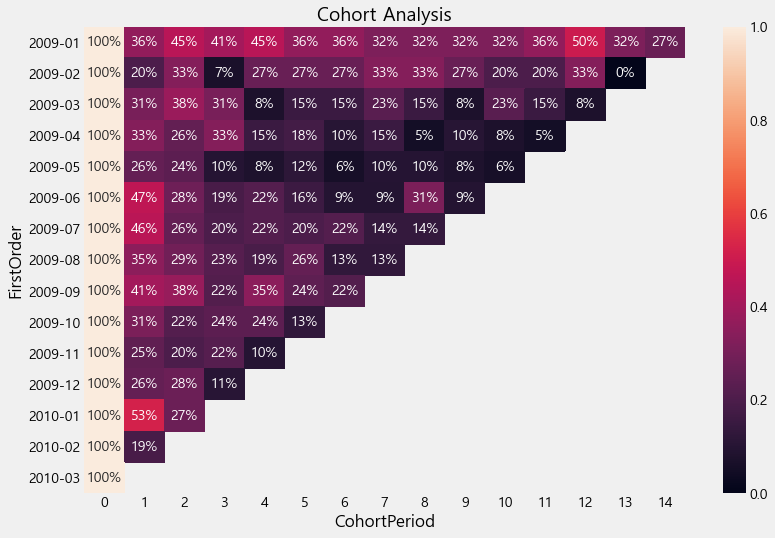

In [36]:
plt.figure(figsize=(12, 8))
plt.title('Cohort Analysis', fontsize=19)
sns.heatmap(user_retention, annot=True, fmt='.0%')
plt.show()

시각화 라이브러리 Seaborn을 사용하면 분석에 대한 결과를 시각적으로 표현할 수 있다. 코호트 분석의 시각화에는 히트맵을 그려주는 heatmap 함수가 사용된다. 이 때 annot 매개변수는 각 데이터를 히트맵상에 표기할 것인지르를 불리언으로 결정한다. 또 fmt 매개변수는 숫자 표시형식인데, 입력된 .0%는 백분율로 표현하되, 1의 자리까지 표현하라는 뜻이다. 